<a href="https://colab.research.google.com/github/UmaBanik/CSE468-Assignment/blob/main/CIFAR10_custom_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training CIFAR-10 Dataset with Custom CNN

## Setup

In [1]:
!pip install -q datasets torchmetrics

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score
import seaborn as sns
from datasets import load_dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 13.1 MB/s eta 0:00:00
Using device: cuda


## Dataset Loading

In [2]:
dataset = load_dataset('uoft-cs/cifar10')

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('Dataset loaded.')
print(f"Train samples : {len(dataset['train'])}")
print(f"Test samples  : {len(dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset loaded.
Train samples : 50000
Test samples  : 10000


## Data Preprocessing

In [3]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [4]:
class CIFAR10Dataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['img']
        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, item['label']


full_train = CIFAR10Dataset(dataset['train'], transform=train_transform)
test_dataset = CIFAR10Dataset(dataset['test'],  transform=test_transform)

train_size = 45000
val_size   = 5000
train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(42))

val_dataset.dataset = CIFAR10Dataset(dataset['train'], transform=test_transform)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 45000 | Val: 5000 | Test: 10000


In [5]:
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## Model Definition

In [6]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3,   64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,  64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


model = CIFAR10CNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 3,249,994
CIFAR10CNN(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Ma

## Training

In [9]:
EPOCHS    = 50
LR        = 3e-4
PATIENCE  = 15

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


In [10]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / total
    train_acc  = 100.0 * correct / total

    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = 100.0 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step()

    print(f'Epoch [{epoch:3d}/{EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print('Training complete. Best model saved as best_model.pth')

Epoch [  1/50]  Train Loss: 1.4930  Train Acc: 55.63%  Val Loss: 1.2709  Val Acc: 66.00%
Epoch [  2/50]  Train Loss: 1.4214  Train Acc: 59.60%  Val Loss: 1.2099  Val Acc: 70.14%
Epoch [  3/50]  Train Loss: 1.3695  Train Acc: 62.42%  Val Loss: 1.1456  Val Acc: 72.70%
Epoch [  4/50]  Train Loss: 1.3211  Train Acc: 64.47%  Val Loss: 1.1025  Val Acc: 75.30%
Epoch [  5/50]  Train Loss: 1.2973  Train Acc: 66.00%  Val Loss: 1.0629  Val Acc: 76.52%
Epoch [  6/50]  Train Loss: 1.2639  Train Acc: 67.51%  Val Loss: 1.0538  Val Acc: 76.84%
Epoch [  7/50]  Train Loss: 1.2344  Train Acc: 69.10%  Val Loss: 1.0653  Val Acc: 77.24%
Epoch [  8/50]  Train Loss: 1.2124  Train Acc: 70.12%  Val Loss: 1.0203  Val Acc: 78.28%
Epoch [  9/50]  Train Loss: 1.1900  Train Acc: 71.25%  Val Loss: 1.0226  Val Acc: 78.40%
Epoch [ 10/50]  Train Loss: 1.1722  Train Acc: 72.22%  Val Loss: 0.9863  Val Acc: 79.90%
Epoch [ 11/50]  Train Loss: 1.1605  Train Acc: 72.65%  Val Loss: 0.9633  Val Acc: 80.72%
Epoch [ 12/50]  Train

## Displaying Evaluation Metrics

In [11]:
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='weighted') * 100
recall    = recall_score(all_labels, all_preds, average='weighted') * 100
f1        = f1_score(all_labels, all_preds, average='weighted') * 100

print(f'Test Accuracy  : {acc:.2f}%')
print(f'Precision      : {precision:.2f}%')
print(f'Recall         : {recall:.2f}%')
print(f'F1 Score       : {f1:.2f}%')
print()
print('Per-class report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test Accuracy  : 88.11%
Precision      : 88.07%
Recall         : 88.11%
F1 Score       : 88.00%

Per-class report:
              precision    recall  f1-score   support

    airplane       0.90      0.89      0.90      1000
  automobile       0.95      0.96      0.96      1000
        bird       0.87      0.80      0.83      1000
         cat       0.81      0.69      0.74      1000
        deer       0.85      0.89      0.87      1000
         dog       0.78      0.85      0.81      1000
        frog       0.89      0.93      0.91      1000
       horse       0.91      0.92      0.91      1000
        ship       0.93      0.94      0.94      1000
       truck       0.92      0.94      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 7. Visualization

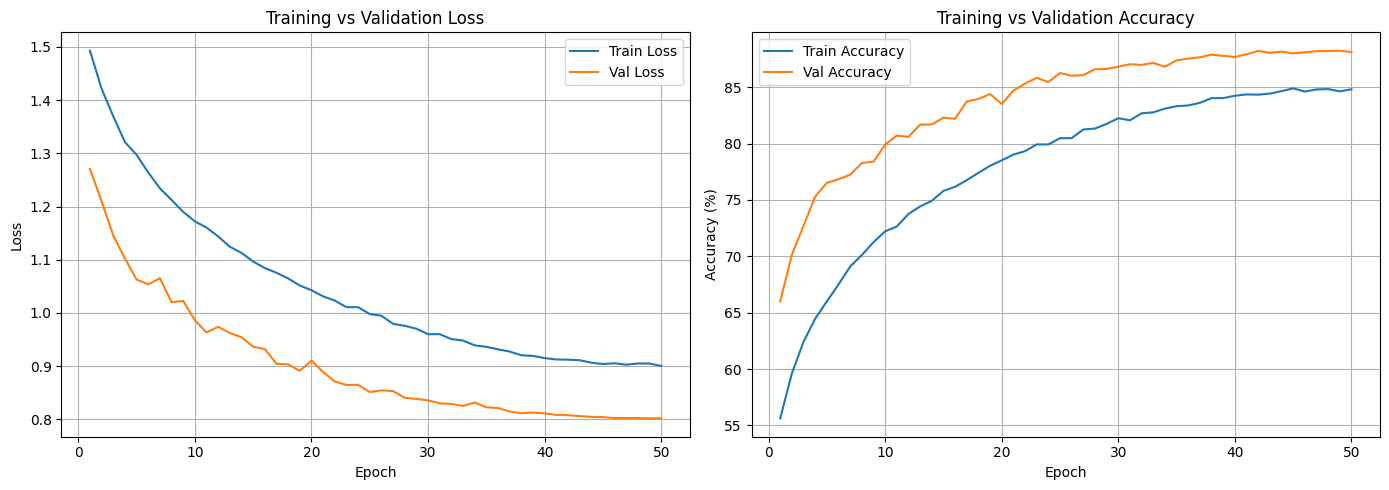

In [12]:
epochs_ran = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_losses, label='Train Loss')
axes[0].plot(epochs_ran, val_losses,   label='Val Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, train_accs, label='Train Accuracy')
axes[1].plot(epochs_ran, val_accs,   label='Val Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=150)
plt.show()

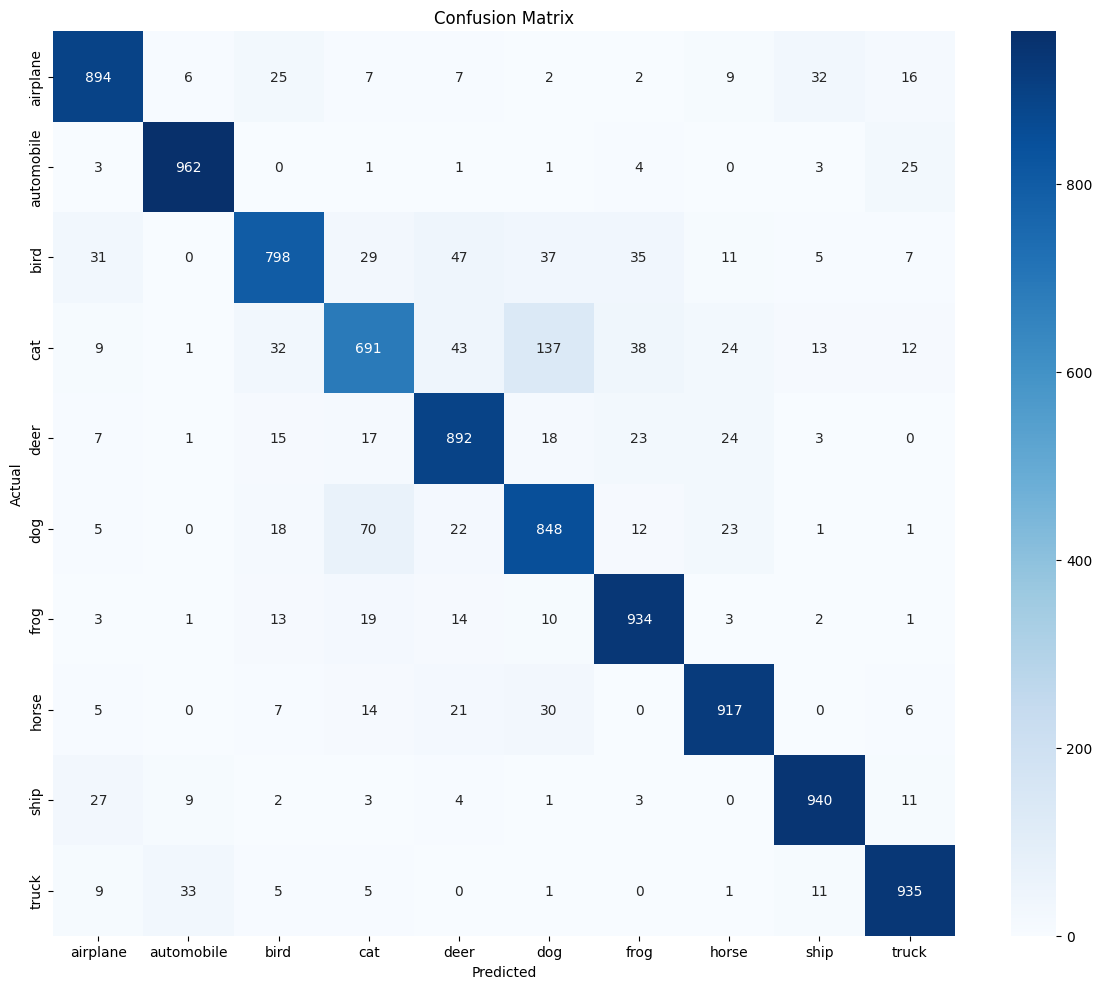

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Single Image Prediction